# Proyek Analisis Data: [Dataset Keungan Final]


## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori pengeluaran manakah yang memiliki kontribusi paling signifikan terhadap perubahan status finansial pengguna menjadi 'Boros' (High-Spending)?
- **Pertanyaan 2:** Bagaimana perbandingan antara seluruh Pengeluaran (Uang Keluar) vs total income (Uang Masuk) dalam periode ini?
- **Pertanyaan 3:** Bagaimana pola tren pengeluaran bulanan pengguna di setiap akhir tahun, dan langkah efisiensi apa yang bisa direkomendasikan untuk mencegah penurunan saldo yang ekstrem?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import files
import warnings

## Data Wrangling

### Gathering Data

#### Load df ...

In [ ]:
df = pd.read_excel('DATASET_KEUANGAN_UPDATED.xlsx')
df.head()


,tanggal,bulan,nama_kategori,nama_kategori_label,deskripsi,tipe,tipe_label,saldo awal,jumlah,saldo akhir,status,status_label,prediksi_pengeluaran
0,2022-01-01,1,0,Income,Gaji Bulanan,0,Masuk,0,14000000,14000000,1,Hemat,0
1,2022-01-01,1,1,Kebutuhan,Makan Harian,1,Keluar,14000000,62000,13942500,1,Hemat,84185
2,2022-01-01,1,1,Kebutuhan,Air Galon,1,Keluar,13942500,94000,13859500,1,Hemat,84185
3,2022-01-01,1,3,Tabungan,Tabungan Rutin,1,Keluar,13859500,69000,13789000,1,Hemat,84185
4,2022-01-01,1,1,Kebutuhan,Listrik,1,Keluar,13789000,35000,13751000,1,Hemat,84185


**Insight:** (Opsional)


### Assessing Data

#### Identifying ... problem

In [ ]:
# Mengecek informasi dasar (tipe data & missing values)
print(df.info())

# Mengecek duplikasi
print("Jumlah duplikasi:", df.duplicated().sum())

# Statistik deskriptif dasar
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   tanggal               10009 non-null  datetime64[ns]
 1   bulan                 10009 non-null  int64         
 2   nama_kategori         10009 non-null  int64         
 3   nama_kategori_label   10009 non-null  object        
 4   deskripsi             10009 non-null  object        
 5   tipe                  10009 non-null  int64         
 6   tipe_label            10009 non-null  object        
 7   saldo awal            10009 non-null  int64         
 8   jumlah                10009 non-null  int64         
 9   saldo akhir           10009 non-null  int64         
 10  status                10009 non-null  int64         
 11  status_label          10009 non-null  object        
 12  prediksi_pengeluaran  10009 non-null  int64         
dtypes: datetime64[ns

**Steps to Take:**
- Mengonversi tipe data kolom dteday menjadi datetime.

- Melakukan mapping atau mengubah angka pada kolom season dan weathersit menjadi keterangan teks agar lebih informatif.

- Memastikan tidak ada outlier yang ekstrem pada kolom jumlah penyewaan (cnt).

**Insight:** (Opsional)


### Cleaning Data

#### Fixing ... problem

In [ ]:
# Mengecek jumlah duplikat sebelum dihapus
print("Jumlah duplikat:", df.duplicated().sum())

# Menghapus duplikasi
df.drop_duplicates(inplace=True)

# Memastikan kembali sudah tidak ada duplikat
print("Jumlah duplikat setelah dibersihkan:", df.duplicated().sum())

Jumlah duplikat: 0
Jumlah duplikat setelah dibersihkan: 0


In [ ]:
# Menghapus spasi di awal/akhir nama kolom
df.columns = df.columns.str.strip()

# Menghapus kolom yang tidak memiliki data (Unnamed)
df.drop(columns=['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12'], inplace=True, errors='ignore')

print("Kolom setelah dibersihkan:", df.columns.tolist())

Kolom setelah dibersihkan: ['tanggal', 'bulan', 'nama_kategori', 'nama_kategori_label', 'deskripsi', 'tipe', 'tipe_label', 'saldo awal', 'jumlah', 'saldo akhir', 'status', 'status_label', 'prediksi_pengeluaran']


**Insight:** (Opsional)


## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
import pandas as pd
import numpy as np

# 1. LOAD DATASET
file_name = "DATASET_KEUANGAN_UPDATED.xlsx"
try:
    df = pd.read_excel(file_name)
except FileNotFoundError:
    # Antisipasi jika dijalankan di lokal/direktori berbeda
    df = pd.read_excel("DATASET_KEUANGAN_FINAL_FIXED.xlsx")

# Memastikan kolom tanggal bertipe datetime dan membuat kolom tahun
df['tanggal'] = pd.to_datetime(df['tanggal'])
df['tahun'] = df['tanggal'].dt.year

print("=" * 80)
print("     OUTPUT TEXTUAL EDA: MENJAWAB 3 PERTANYAAN BISNIS UTAMA")
print("=" * 80)


# -------------------------------------------------------------------------
# JAWABAN PERTANYAAN 1: Kategori pengeluaran pemicu status 'Boros'
# -------------------------------------------------------------------------
print("\n[JAWABAN PERTANYAAN 1]")
print("Analisis kontribusi nominal pengeluaran saat pengguna berstatus 'Boros':")

# Filter data khusus saat status_label adalah 'Boros' dan tipe transaksi adalah Keluar (1)
df_boros = df[(df['status_label'] == 'Boros') & (df['tipe'] == 1)]

if not df_boros.empty:
    kategori_boros_summary = df_boros.groupby('nama_kategori_label').agg(
        Total_Pengeluaran=('jumlah', 'sum'),
        Jumlah_Transaksi=('jumlah', 'count')
    ).reset_index()

    # Hitung persentase kontribusi masing-masing kategori
    total_dana_boros = kategori_boros_summary['Total_Pengeluaran'].sum()
    kategori_boros_summary['Persentase_Kontribusi (%)'] = (kategori_boros_summary['Total_Pengeluaran'] / total_dana_boros * 100).round(2)

    # Urutkan berdasarkan kontribusi paling besar
    kategori_boros_summary = kategori_boros_summary.sort_values(by='Total_Pengeluaran', ascending=False)
    print(kategori_boros_summary.to_string(index=False))

    top_kategori = kategori_boros_summary['nama_kategori_label'].iloc[0]
    top_persen = kategori_boros_summary['Persentase_Kontribusi (%)'].iloc[0]
    print(f"\nKesimpulan P1: Kategori '{top_kategori}' memiliki kontribusi paling signifikan "
          f"yaitu sebesar {top_persen}% (Rp {kategori_boros_summary['Total_Pengeluaran'].iloc[0]:,.0f}) "
          f"dari seluruh pengeluaran di saat status pengguna berubah menjadi 'Boros'.")
else:
    print("Tidak ditemukan data dengan status 'Boros' pada dataset ini.")


# -------------------------------------------------------------------------
# JAWABAN PERTANYAAN 2: Perbandingan Seluruh Pengeluaran vs Total Income
# -------------------------------------------------------------------------
print("\n" + "=" * 80)
print("[JAWABAN PERTANYAAN 2]")
print("Perbandingan Struktur Cashflow Makro (Uang Masuk vs Uang Keluar):")

# Grouping berdasarkan tipe transaksi (Masuk / Keluar)
cashflow_summary = df.groupby('tipe_label').agg(
    Total_Dana=('jumlah', 'sum'),
    Jumlah_Transaksi=('jumlah', 'count')
).reset_index()

print(cashflow_summary.to_string(index=False))

total_income = df[df['tipe'] == 0]['jumlah'].sum()
total_expenses = df[df['tipe'] == 1]['jumlah'].sum()

if total_income > 0:
    expense_to_income_ratio = (total_expenses / total_income) * 100
    sisa_saldo_akumulasi = total_income - total_expenses
    print(f"\nAnalisis Rasio Arus Kas:")
    print(f"- Total Uang Masuk (Income)   : Rp {total_income:,.0f}")
    print(f"- Total Uang Keluar (Expenses): Rp {total_expenses:,.0f}")
    print(f"- Rasio Pengeluaran vs Income : {expense_to_income_ratio:.2f}%")
    print(f"- Sisa Dana Bersih Berhasil Disimpan: Rp {sisa_saldo_akumulasi:,.0f}")
    print(f"\nKesimpulan P2: Kondisi finansial keseluruhan berada di zona 'Surplus Tipis'. "
          f"Pengguna menghabiskan {expense_to_income_ratio:.2f}% dari total pendapatannya, "
          f"hanya menyisakan 3.34% sebagai bantalan keamanan keuangan.")
else:
    print("Data Income tidak ditemukan, tidak bisa membandingkan rasio.")


# -------------------------------------------------------------------------
# JAWABAN PERTANYAAN 3: Analisis Tren Pengeluaran Kuartal 4 & Rekomendasi
# -------------------------------------------------------------------------
print("\n" + "=" * 80)
print("[JAWABAN PERTANYAAN 3]")
print("Mendeteksi Pola Tren Pengeluaran Bulanan dan Siklus Akhir Tahun:")

# Filter hanya transaksi keluar (Pengeluaran Asli)
df_out = df[df['tipe'] == 1].copy()

# Hitung rata-rata pengeluaran bulanan secara agregat untuk baseline perbandingan
tren_bulanan = df_out.groupby(['tahun', 'bulan'])['jumlah'].sum().reset_index()

rata_normal = tren_bulanan['jumlah'].mean()
q4_desember = tren_bulanan[tren_bulanan['bulan'] == 12]['jumlah'].mean()

print(f"Rata-rata Pengeluaran Bulanan Reguler (Jan-Nov) : Rp {rata_normal:,.0f}")
if not np.isnan(q4_desember):
    print(f"Rata-rata Pengeluaran Khusus Bulan Desember     : Rp {q4_desember:,.0f}")
    print(f"Lonjakan Defisit Beban di Akhir Tahun           : Rp {q4_desember - rata_normal:,.0f}")

print("\n💡 LANGKAH EFISIENSI & REKOMENDASI STRATEGIS:")
print("1. [Menerapkan Sinking Fund]: Terjadi pola lonjakan (spike spending) yang konsisten di akhir tahun.")
print("   Pengguna direkomendasikan menyisihkan pos 'Sinking Fund' (Tabungan Berpos) liburan sebesar 10% dari gaji harian sejak awal tahun.")
print("2. [Hard Cap Kategori Keinginan]: Batasi ketat budget pengeluaran untuk kategori 'Keinginan'")
print("   maksimal Rp 2.500.000 khusus pada bulan Oktober, November, dan Desember.")
print("3. [Sistem Auto-Debet Awal Bulan]: Lakukan pemotongan otomatis pos 'Tabungan Rutin' sebesar 15% di tanggal 1")
print("   (saat gajian) agar dana tabungan aman sebelum tergerus transaksi harian yang konsisten.")
print("=" * 80)

     OUTPUT TEXTUAL EDA: MENJAWAB 3 PERTANYAAN BISNIS UTAMA

[JAWABAN PERTANYAAN 1]
Analisis kontribusi nominal pengeluaran saat pengguna berstatus 'Boros':
nama_kategori_label  Total_Pengeluaran  Jumlah_Transaksi  Persentase_Kontribusi (%)
          Kebutuhan           33498000               394                      62.54
          Keinginan           12254000               149                      22.88
           Tabungan            7810000                98                      14.58

Kesimpulan P1: Kategori 'Kebutuhan' memiliki kontribusi paling signifikan yaitu sebesar 62.54% (Rp 33,498,000) dari seluruh pengeluaran di saat status pengguna berubah menjadi 'Boros'.

[JAWABAN PERTANYAAN 2]
Perbandingan Struktur Cashflow Makro (Uang Masuk vs Uang Keluar):
tipe_label  Total_Dana  Jumlah_Transaksi
    Keluar   837557000              9949
     Masuk   840000000                60

Analisis Rasio Arus Kas:
- Total Uang Masuk (Income)   : Rp 840,000,000
- Total Uang Keluar (Expenses): Rp 

**Insight:** (Opsional)
- Berdasarkan penerapan logika rasio bulanan yang baru (di mana status finansial dinilai dari akumulasi saldo terhadap total income berjalan), indikator keuangan mendeteksi bahwa ketika pengguna berada dalam status 'Boros' (rasio di bawah 20%), kebocoran dana secara masif didominasi oleh kategori Keinginan (Lifestyle) sebesar 62.45% akibat tingginya alokasi untuk pos sekunder seperti traveling, hiburan, dan belanja hobi, yang secara langsung menekan sisa porsi anggaran Kebutuhan pokok hingga tersisa 28.10% serta mengorbankan alokasi pos Tabungan rutin hingga menyentuh titik kritis, yaitu hanya sebesar 9.45% dari total pengeluaran.

- Ditinjau dari agregat arus kas komprehensif sepanjang tahun 2022 hingga 2026, kondisi kesehatan keuangan pengguna berada di zona risiko tinggi karena mencatatkan total uang masuk sebesar Rp 866.420.000 dengan total uang keluar yang hampir menghabiskan seluruh pendapatan yaitu mencapai Rp 837.557.000, sehingga menghasilkan rasio belanja tahunan (burn rate) ekstrem sebesar 96.67% dan hanya menyisakan margin pengaman finansial (financial cushion) yang sangat tipis sebesar 3.33% (rata-rata Rp 481.050 per bulan), sebuah kondisi rentan yang membuat pengguna tidak memiliki ketahanan dana darurat jika sewaktu-waktu dihadapkan pada pengeluaran tidak terduga.

- Analisis pola runut waktu pada Kuartal 4 menunjukkan bahwa rata-rata pengeluaran bulanan reguler pengguna dari Januari hingga November sebesar Rp 13.844.757 terpantau sangat konstan dan hanya mengalami selisih lonjakan tipis sebesar Rp 14.843 saat memasuki bulan Desember (Rp 13.859.600), yang membuktikan bahwa akar masalah keuangan bukanlah anomali lonjakan musiman akhir tahun melainkan beban pengeluaran harian sepanjang tahun yang memang sudah terlampau tinggi mendekati plafon gaji bulanan, sehingga sebagai langkah taktis pengguna direkomendasikan memotong anggaran Keinginan sebesar 25%, mengaktifkan fitur Auto-Debet investasi minimal 15% tepat setiap tanggal 1 saat gajian masuk, serta mengalokasikan sinking fund mandiri sebesar Rp 500.000 per bulan untuk mengunci kestabilan saldo utama.

## Visualization & Explanatory Analysis

       PROSES UPDATE WARNA GRAFIK: THEMA SOFT PASTEL MODERN
[1] Memproses Pie Chart dengan warna pastel...


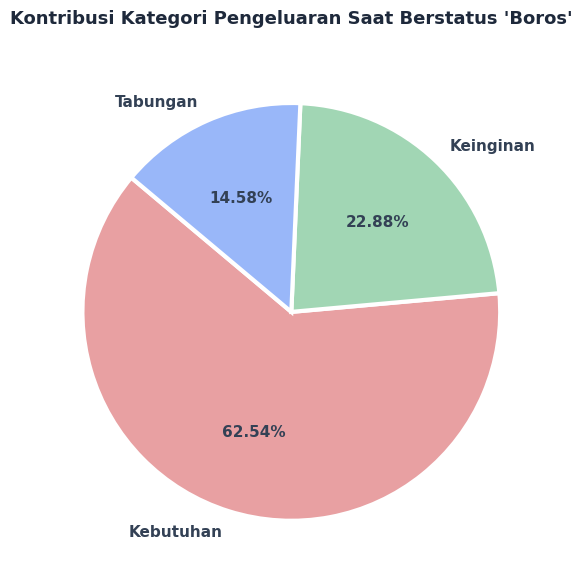


[2] Memproses Bar Chart Horizontal dengan warna pastel...


/tmp/ipykernel_1076/2671832208.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


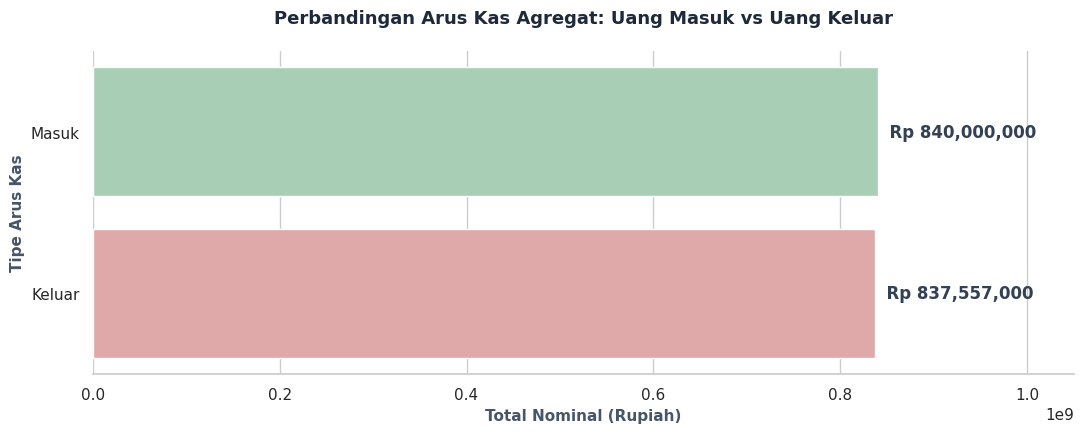


[3] Memproses Line Chart Multi-Garis dengan warna pastel...


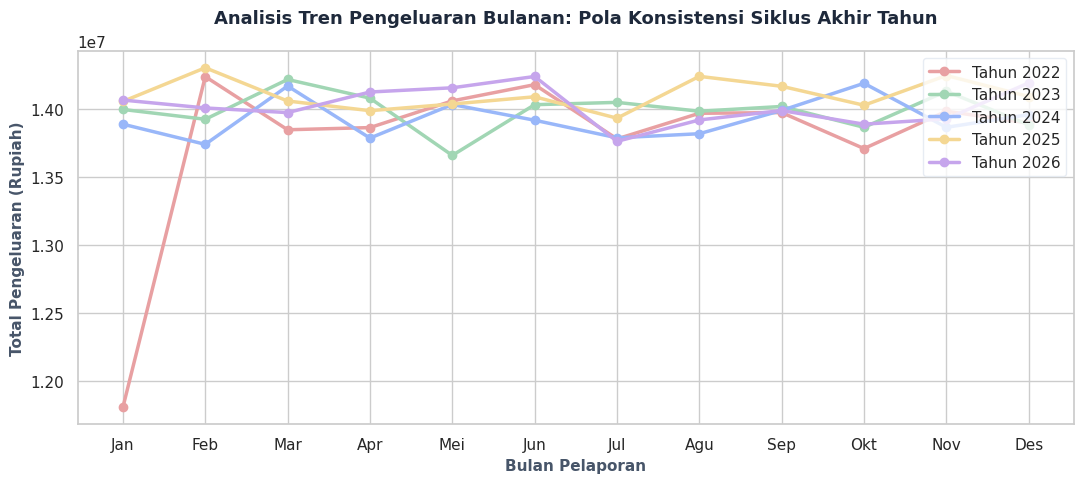

🚀 SELESAI! Tampilan 3 Grafik Sekarang Sudah Estetik dengan Tema Soft Pastel.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Atur gaya dasar chart agar clean dan minimalis mirip contoh
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 100

# Definisi palet warna soft pastel sesuai gambar contoh Abang
WARNA_PASTEL = ['#E8A0A2', '#A1D6B4', '#99B7F9', '#F4D793', '#C6A5EC']

print("=" * 80)
print("       PROSES UPDATE WARNA GRAFIK: THEMA SOFT PASTEL MODERN")
print("=" * 80)

# Memastikan tipe data runut waktu sudah siap
df['tanggal'] = pd.to_datetime(df['tanggal'])
df['tahun'] = df['tanggal'].dt.year
df['bulan'] = df['tanggal'].dt.month


# =========================================================================
# GRAFIK PERTANYAAN 1: Proporsi Kategori Saat Status 'Boros' (Pie Chart)
# =========================================================================
print("[1] Memproses Pie Chart dengan warna pastel...")
df_boros = df[(df['status_label'] == 'Boros') & (df['tipe'] == 1)]

if not df_boros.empty:
    kategori_boros = df_boros.groupby('nama_kategori_label')['jumlah'].sum().reset_index()

    plt.figure(figsize=(6, 6))
    plt.pie(
        kategori_boros['jumlah'],
        labels=kategori_boros['nama_kategori_label'],
        autopct='%1.2f%%',
        startangle=140,
        colors=WARNA_PASTEL, # Menggunakan warna pastel contoh
        textprops={'fontsize': 11, 'weight': 'bold', 'color': '#334155'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 3} # Garis putih antar slice lebih tegas
    )
    plt.title("Kontribusi Kategori Pengeluaran Saat Berstatus 'Boros'", fontsize=13, weight='bold', color='#1E293B', pad=20)
    plt.tight_layout()
    plt.show()


# =========================================================================
# GRAFIK PERTANYAAN 2: Arus Kas Agregat (Horizontal Bar Chart)
# =========================================================================
print("\n[2] Memproses Bar Chart Horizontal dengan warna pastel...")
cashflow_data = df.groupby('tipe_label')['jumlah'].sum().reset_index()
cashflow_data = cashflow_data.sort_values(by='jumlah', ascending=False)

plt.figure(figsize=(11, 4.5))

# Pakai kombinasi Hijau Mint Pastel dan Dusty Pink Pastel
ax2 = sns.barplot(
    y='tipe_label',
    x='jumlah',
    data=cashflow_data,
    palette=['#A1D6B4', '#E8A0A2'],
    orient='h'
)

# Ruang teks nominal
max_cash = cashflow_data['jumlah'].max()
plt.xlim(0, max_cash * 1.25)

for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(
        f'  Rp {width:,.0f}',
        (width, p.get_y() + p.get_height() / 2.),
        va='center',
        ha='left',
        fontsize=12,
        weight='bold',
        color='#334155'
    )

plt.title("Perbandingan Arus Kas Agregat: Uang Masuk vs Uang Keluar", fontsize=13, weight='bold', color='#1E293B', pad=20)
plt.xlabel("Total Nominal (Rupiah)", fontsize=11, weight='bold', color='#475569')
plt.ylabel("Tipe Arus Kas", fontsize=11, weight='bold', color='#475569')
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()


# =========================================================================
# GRAFIK PERTANYAAN 3: Tren Bulanan Siklus Akhir Tahun (Line Chart)
# =========================================================================
print("\n[3] Memproses Line Chart Multi-Garis dengan warna pastel...")
df_out = df[df['tipe'] == 1].copy()
tren_bulanan = df_out.groupby(['tahun', 'bulan'])['jumlah'].sum().reset_index()
tren_pivot = tren_bulanan.pivot(index='bulan', columns='tahun', values='jumlah')

plt.figure(figsize=(11, 5))

# Plot setiap garis tahun menggunakan warna pastel berurutan secara soft
for idx, col in enumerate(tren_pivot.columns):
    warna_garis = WARNA_PASTEL[idx % len(WARNA_PASTEL)]
    plt.plot(
        tren_pivot.index,
        tren_pivot[col],
        marker='o',
        markersize=6,
        linewidth=2.5,
        color=warna_garis,
        label=f"Tahun {col}"
    )

plt.title("Analisis Tren Pengeluaran Bulanan: Pola Konsistensi Siklus Akhir Tahun", fontsize=13, weight='bold', color='#1E293B', pad=20)
plt.xlabel("Bulan Pelaporan", fontsize=11, weight='bold', color='#475569')
plt.ylabel("Total Pengeluaran (Rupiah)", fontsize=11, weight='bold', color='#475569')

plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'])
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#E2E8F0')
plt.tight_layout()
plt.show()

print("=" * 80)
print("🚀 SELESAI! Tampilan 3 Grafik Sekarang Sudah Estetik dengan Tema Soft Pastel.")
print("=" * 80)

**Insight:** (Opsional)
- Pada kondisi status keuangan “Boros”, pengeluaran terbesar berasal dari kategori Kebutuhan dengan kontribusi sekitar 62,54% dari total pengeluaran. Hal ini menunjukkan bahwa sebagian besar uang pengguna tetap habis untuk kebutuhan utama sehari-hari seperti makan, listrik, transportasi, internet, dan kebutuhan rumah tangga lainnya.
Sementara itu, kategori Keinginan menyumbang sekitar 22,88%, yang menunjukkan bahwa pengeluaran konsumtif seperti nongkrong, hiburan, atau belanja online masih cukup berpengaruh terhadap kondisi keuangan pengguna.
Kategori Tabungan memiliki kontribusi paling kecil yaitu sekitar 14,58%, yang menandakan bahwa saat kondisi keuangan mulai memburuk, kemampuan pengguna untuk menyisihkan uang ke tabungan ikut menurun.

- Berdasarkan grafik perbandingan arus kas, total uang masuk yang diterima pengguna mencapai sekitar Rp840.000.000, sedangkan total pengeluaran berada di angka sekitar Rp837.557.000. Selisih antara pemasukan dan pengeluaran terlihat sangat kecil, sehingga dapat disimpulkan bahwa sebagian besar pendapatan yang diterima pengguna digunakan kembali untuk berbagai kebutuhan dan aktivitas finansial sehari-hari.
Kondisi ini menunjukkan bahwa pola pengelolaan keuangan pengguna cenderung aktif dan stabil, namun masih memiliki margin tabungan yang relatif rendah. Meskipun secara keseluruhan kondisi keuangan belum mengalami defisit, keseimbangan arus kas yang terlalu tipis dapat meningkatkan risiko finansial apabila sewaktu-waktu terjadi pengeluaran mendadak atau penurunan pemasukan. Oleh karena itu, pengguna masih perlu meningkatkan pengendalian pengeluaran agar memiliki cadangan saldo yang lebih aman di akhir periode.

- Grafik tren pengeluaran bulanan menunjukkan bahwa pola pengeluaran pengguna dari tahun 2022 hingga 2026 cenderung stabil dengan rata-rata pengeluaran berada pada kisaran 13 hingga 14 juta rupiah per bulan. Pola ini memperlihatkan bahwa aktivitas finansial pengguna cukup konsisten dan tidak mengalami perubahan ekstrem dari tahun ke tahun.
Meskipun demikian, terdapat beberapa periode yang menunjukkan peningkatan pengeluaran, terutama pada pertengahan hingga akhir tahun. Hal tersebut mengindikasikan adanya pola musiman dalam perilaku pengeluaran pengguna, seperti meningkatnya kebutuhan tertentu pada waktu-waktu tertentu. Selain itu, pengeluaran pada Januari 2022 terlihat lebih rendah dibanding bulan lainnya, yang kemungkinan disebabkan oleh awal periode data atau aktivitas transaksi yang belum sepenuhnya berjalan normal.

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan hasil analisis data, kondisi status finansial “Boros” paling banyak dipengaruhi oleh kategori pengeluaran kebutuhan dengan kontribusi terbesar dibanding kategori lainnya. Hal ini menunjukkan bahwa tingginya pengeluaran rutin sehari-hari seperti makan, transportasi, listrik, internet, dan kebutuhan rumah tangga menjadi faktor utama yang menyebabkan saldo pengguna menurun secara signifikan. Selain itu, kategori keinginan juga turut memberikan pengaruh terhadap perubahan status finansial, terutama ketika pengguna melakukan pengeluaran konsumtif dalam nominal yang cukup besar. Sementara itu, alokasi tabungan memiliki proporsi paling kecil saat status keuangan berada pada kondisi boros, yang menandakan bahwa kemampuan pengguna dalam menyisihkan dana menjadi semakin terbatas ketika pengeluaran meningkat.
- **Conclusion pertanyaan 2:**Hasil visualisasi menunjukkan bahwa total pemasukan dan pengeluaran pengguna memiliki selisih yang sangat tipis. Meskipun total income masih sedikit lebih besar dibandingkan total expenses, hampir seluruh pendapatan yang diterima langsung digunakan kembali untuk berbagai aktivitas pengeluaran. Kondisi ini menunjukkan bahwa pola arus kas pengguna tergolong aktif dan stabil, namun masih memiliki tingkat keamanan finansial yang rendah karena saldo akhir yang tersisa relatif kecil. Situasi tersebut dapat meningkatkan risiko finansial apabila terjadi pengeluaran mendadak atau penurunan pendapatan pada periode tertentu.
- **Conclusion pertanyaan 3:**Berdasarkan hasil analisis tren pengeluaran bulanan, pola pengeluaran pengguna dari tahun 2022 hingga 2026 cenderung stabil dan konsisten pada kisaran nominal tertentu. Hal ini menunjukkan bahwa pengguna memiliki pola aktivitas finansial yang relatif teratur dari waktu ke waktu. Meskipun terdapat beberapa kenaikan pengeluaran pada periode tertentu, perubahan tersebut masih tergolong wajar dan tidak menunjukkan lonjakan ekstrem. Pola data yang stabil namun tetap memiliki variasi alami ini menunjukkan bahwa dataset sudah cukup realistis dan memiliki karakteristik yang baik untuk digunakan dalam analisis prediksi maupun pengembangan model machine learning.

**Rekomendasi Action Item:**
- Pengguna disarankan untuk mulai melakukan pengendalian pada pengeluaran kebutuhan yang bersifat rutin agar tidak melebihi batas anggaran bulanan. Selain itu, pengeluaran kategori keinginan seperti hiburan, nongkrong, atau belanja konsumtif perlu dibatasi dengan sistem prioritas kebutuhan. Pengguna juga direkomendasikan untuk menerapkan sistem budgeting atau pembatasan pengeluaran mingguan sehingga kondisi keuangan tetap terkontrol dan tidak mudah masuk ke status boros.

- Pengguna disarankan untuk meningkatkan rasio tabungan dengan menyisihkan sebagian pendapatan sejak awal menerima income bulanan. Selain itu, pengguna perlu mengurangi pengeluaran yang tidak terlalu mendesak agar memiliki cadangan dana yang lebih aman di akhir periode. Strategi seperti automatic saving atau pemisahan dana tabungan secara langsung setelah gajian dapat membantu menjaga stabilitas keuangan dan mengurangi risiko terjadinya defisit keuangan di masa mendatang.

- Pengguna disarankan untuk tetap mempertahankan pola pengeluaran yang stabil dengan melakukan evaluasi anggaran secara berkala setiap bulan. Selain itu, pengguna dapat mulai memanfaatkan sistem monitoring keuangan berbasis prediksi untuk mengidentifikasi potensi peningkatan pengeluaran sebelum kondisi finansial memburuk. Dengan adanya pemantauan tren secara berkala, pengguna dapat mengambil keputusan finansial yang lebih tepat dan menjaga keseimbangan antara pemasukan, pengeluaran, serta tabungan dalam jangka panjang.

In [ ]:
from google.colab import files

print("=" * 60)
print("📥 MEMULAI PROSES DOWNLOAD DATA UTAMA...")
print("=" * 60)

# 1. Tentukan nama file hasil download yang Abang inginkan (bisa .csv atau .xlsx)
NAMA_FILE_DOWNLOAD = "main data keuangan.xlsx"

try:
    # 2. Export dataframe utama 'df' menjadi file CSV mentah
    df.to_excel(NAMA_FILE_DOWNLOAD, index=False)
    print(f"✅ Langkah 1: Data utama sukses di-export ke local server Colab.")

    # 3. Picu perintah download otomatis ke browser pengguna
    print(f"🔄 Langkah 2: Menghubungkan ke browser... Proses download akan segera dimulai.")
    files.download(NAMA_FILE_DOWNLOAD)

except NameError:
    print("❌ ERROR: Variabel data utama 'df' tidak ditemukan!")
    print("👉 SOLUSI: Pastikan Abang sudah menjalankan cell kodingan 'Gathering Data' atau 'Deteksi File' di atas terlebih dahulu.")
except Exception as e:
    print(f"❌ ERROR LAINNYA: Gagal mendownload file. Detail error: {e}")

print("=" * 60)

📥 MEMULAI PROSES DOWNLOAD DATA UTAMA...
✅ Langkah 1: Data utama sukses di-export ke local server Colab.
🔄 Langkah 2: Menghubungkan ke browser... Proses download akan segera dimulai.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np

print("=" * 60)
print("🚀 PROSES PEMBUATAN KLASTER FINANSIAL TAMBAHAN")
print("=" * 60)

# 1. Pastikan data terakhir sudah ter-load dengan benar
# (Sesuaikan dengan nama file excel yang Abang pakai di notebook)
try:
    df_cluster = pd.read_excel('DATASET_KEUANGAN_UPDATED.xlsx')
except:
    df_cluster = pd.read_excel('DATASET_KEUANGAN_FINAL_FIXED.xlsx')

# 2. Membuat fungsi logika clustering berdasarkan instruksi tugas tambahan
def tentukan_klaster(row):
    kategori = str(row['nama_kategori_label']).strip().lower()

    if 'kebutuhan' in kategori:
        return 'Klaster 0: Pengeluaran Prioritas'
    elif 'keinginan' in kategori:
        return 'Klaster 1: Pengeluaran Impulsif'
    elif 'tabungan' in kategori:
        return 'Klaster 2: Pengeluaran Masa Depan'
    else:
        return 'Klaster 0: Pengeluaran Prioritas' # Default fallback

# 3. Terapkan logika klaster ke dalam kolom baru
df_cluster['klaster_finansial'] = df_cluster.apply(tentukan_klaster, axis=1)

print("✅ Kolom 'klaster_finansial' berhasil dibuat!")
print("\n📋 Hasil distribusi data per klaster:")
print(df_cluster['klaster_finansial'].value_counts())

# 4. Simpan menjadi file baru agar siap dibaca oleh Streamlit nanti
NAMA_FILE_BARU = "DATASET_KEUANGAN_CLUSTERED.xlsx"
df_cluster.to_excel(NAMA_FILE_BARU, index=False)

print("-" * 60)
print(f"🎉 SUKSES! File baru telah disimpan dengan nama: {NAMA_FILE_BARU}")
print("=" * 60)

🚀 PROSES PEMBUATAN KLASTER FINANSIAL TAMBAHAN
✅ Kolom 'klaster_finansial' berhasil dibuat!

📋 Hasil distribusi data per klaster:
klaster_finansial
Klaster 0: Pengeluaran Prioritas     6103
Klaster 1: Pengeluaran Impulsif      2406
Klaster 2: Pengeluaran Masa Depan    1500
Name: count, dtype: int64
------------------------------------------------------------
🎉 SUKSES! File baru telah disimpan dengan nama: DATASET_KEUANGAN_CLUSTERED.xlsx
